In [ ]:
%pip install -U ddgs

In [34]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated , List, Any, Literal
from langchain_core.messages import BaseMessage, HumanMessage, AnyMessage
from langchain_openai import ChatOpenAI
from langgraph.graph.message import add_messages
from pydantic import BaseModel

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random
from dotenv import load_dotenv
load_dotenv()

True

In [35]:
llm = ChatOpenAI()

In [ ]:
#tools
searchTool = DuckDuckGoSearchRun(region='us-en')

@tool
def calculator(first_num:float, second_num: float, operation: str) -> dict:
    """
    Perform basic arithmetic operation on two numbers.
    Supported Operations: add, sub, mul, div 

    Args:
        first_num (float): _description_
        second_num (float): _description_
        operation (str): _description_

    Returns:
        dict: _description_
    """
    
    try:
        if operation == "sub":
            result = first_num-second_num
        elif operation == "add":
            result = first_num-second_num
        elif operation == "mul":
            result = first_num*second_num
        elif operation == "div":
            result = first_num/second_num
        else:
            return {"error":f"Unsupported Operation {operation}"}
        
        return result

            
    except Exception as e:
        return {'error':str(e)}

In [65]:
# make tools
tools = [searchTool, calculator]

llm_with_tools = llm.bind_tools(tools=tools)

In [50]:
class State(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]

In [66]:
tool_node = ToolNode(tools=tools)

def chat_node(state: State):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    
    return {"messages":[response]}

In [75]:
graph = StateGraph(State)

graph.add_node("tools",tool_node)
graph.add_node("chat_node",chat_node)

In [76]:
graph.add_edge(START, 'chat_node')
graph.add_conditional_edges("chat_node", tools_condition)
graph.add_edge('tools', 'chat_node')

In [77]:
workflow = graph.compile()

In [68]:
res = workflow.invoke({'messages':[HumanMessage("Hello")]})

print(res["messages"][-1].content)

Hi! How can I assist you today?


In [73]:
res = workflow.invoke({'messages':[HumanMessage("What is 2*2")]})

print(res["messages"][-1].content)

4.0 2.0
4.0


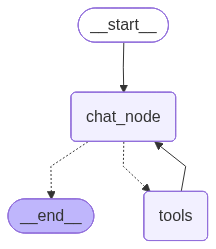

In [79]:
from IPython.display import Image

Image(workflow.get_graph().draw_mermaid_png())